
## Day 3 – Exploratory Data Analysis and Visualization

This notebook focuses on exploratory data analysis of mutual fund industry datasets. Various visualizations are created to analyze NAV trends, AUM growth, SIP inflows, category-wise inflows, investor demographics, geographic distribution, folio growth, portfolio allocation, and fund return correlations. The objective is to identify patterns, trends, and business insights that support investment analysis and dashboard development.


## Day 3 – Exploratory Data Analysis and Visualization

This notebook focuses on exploratory data analysis of mutual fund industry datasets. Various visualizations are created to analyze NAV trends, AUM growth, SIP inflows, category-wise inflows, investor demographics, geographic distribution, folio growth, portfolio allocation, and fund return correlations. The objective is to identify patterns, trends, and business insights that support investment analysis and dashboard development.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


In [6]:
import os

os.makedirs("../reports/charts", exist_ok=True)

def save_chart(name):
    plt.savefig(
        f"../reports/charts/{name}.png",
        bbox_inches="tight",
        dpi=300
    )

In [7]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [8]:
print(aum.columns)
print(sip.columns)
print(category.columns)
print(folios.columns)
print(holdings.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


## NAV Trend Analysis

This visualization shows the daily NAV movement of mutual fund schemes from 2022 to 2026. The objective is to identify long-term growth patterns, market rallies, and correction periods.

In [9]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.1
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.1
)

# Save PNG
fig.write_image(
    "../reports/charts/nav_trend.png"
)

# Display chart
fig.show()

### Insight 1

Most mutual fund schemes exhibited a steady upward NAV trend between 2022 and 2026, indicating consistent long-term wealth creation potential.

**Reference:** Daily NAV Trend (2022–2026)

## AUM Growth Analysis

This chart compares Assets Under Management (AUM) across fund houses over time and highlights the market leadership of SBI Mutual Fund.

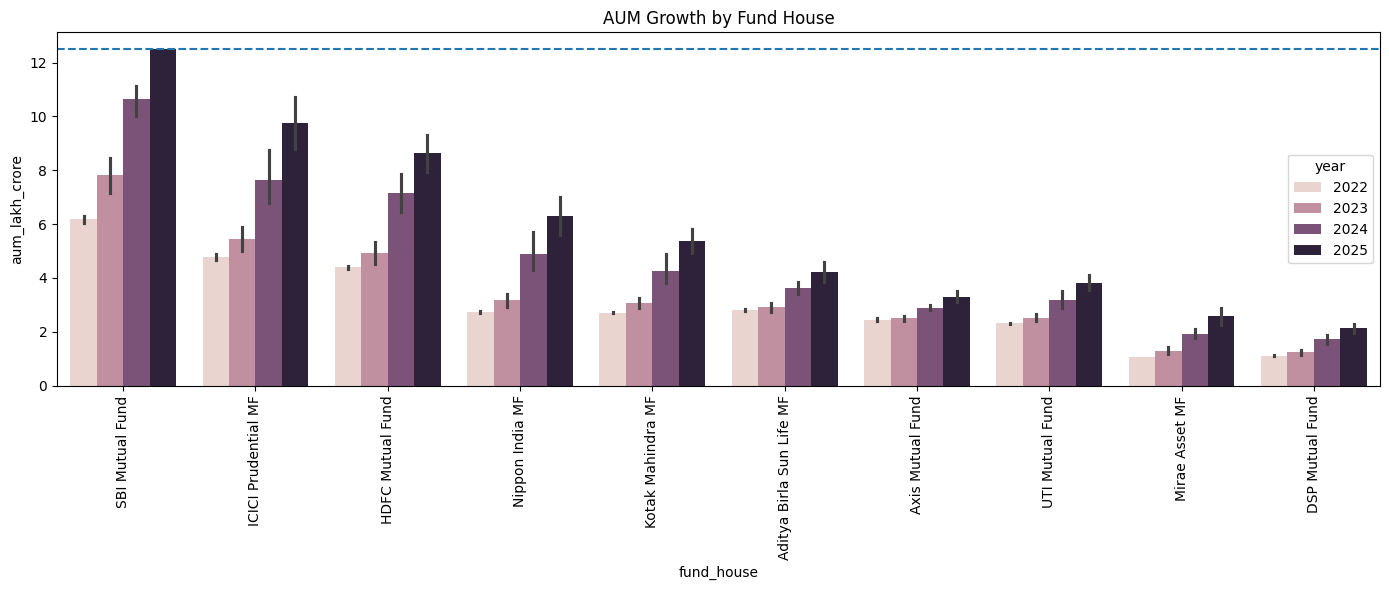

In [42]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)
plt.axhline(
    y=12.5,
    linestyle="--"
)
plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.tight_layout()
plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Insight 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM), demonstrating strong market leadership throughout the analysis period.

**Reference:** AUM Growth by Fund House

## SIP Inflow Trend

Monthly SIP inflows are analysed to understand investor participation trends and growth in systematic investing.

In [26]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=float(max_row["sip_inflow_crore"]),
    text=f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True
)

fig.write_image("../reports/charts/sip_inflow_trend.png")
fig.show()

### Insight 3

Monthly SIP inflows increased consistently, reflecting growing retail investor participation in mutual funds.

**Reference:** Monthly SIP Inflows

### Insight 4

The highest SIP inflow was recorded in December 2025, indicating strong investor confidence and increasing adoption of systematic investment plans.

**Reference:** Monthly SIP Inflows

## Category-wise Fund Flows

The heatmap highlights inflow intensity across different fund categories and time periods.

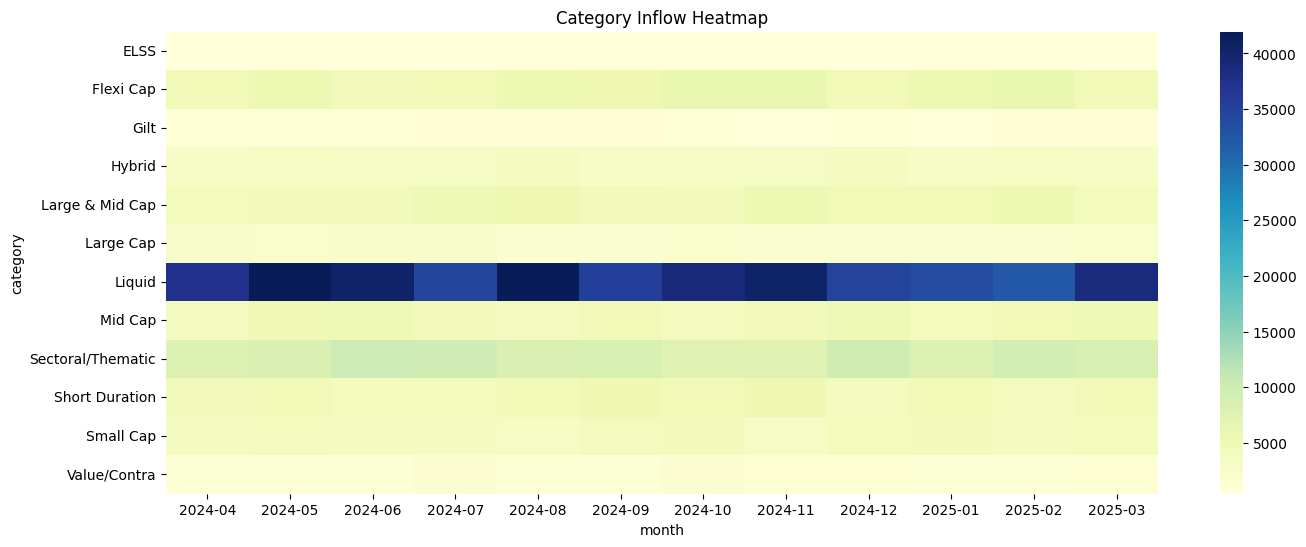

In [28]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.savefig(
    "../reports/charts/category_heatmap.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Insight 5

Equity-oriented fund categories attracted higher inflows compared to most other investment categories.

**Reference:** Category Inflow Heatmap

## Age Group Distribution 

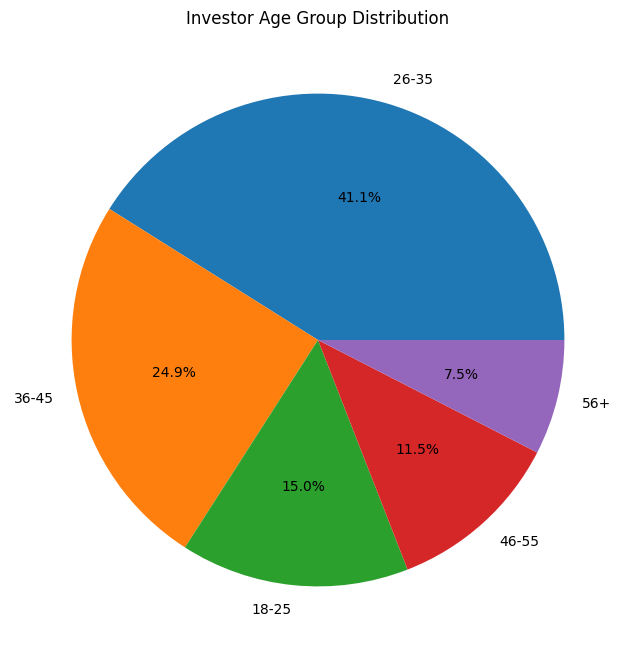

In [29]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.savefig(
    "../reports/charts/age_group_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

## SIP Amount distribution by age 

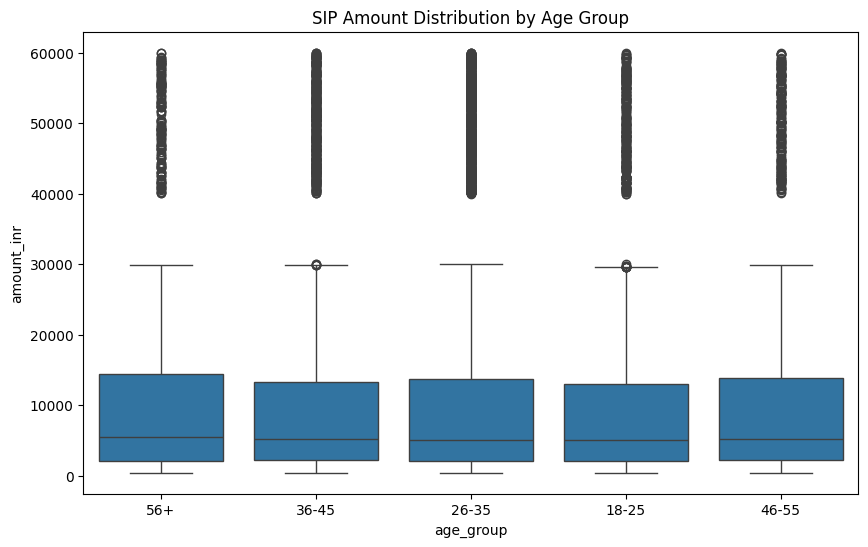

In [30]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.savefig(
    "../reports/charts/sip_boxplot.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Insight 6

Investors belonging to the 26–35 age group contributed the largest share of mutual fund investments.

**Reference:** Age Group Distribution and SIP Amount Distribution by Age Group

## Gender Distribution

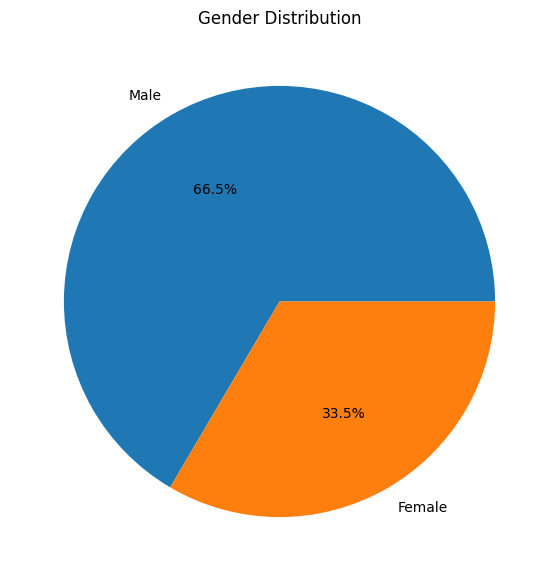

In [31]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.savefig(
    "../reports/charts/gender_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

## SIP Amount by State

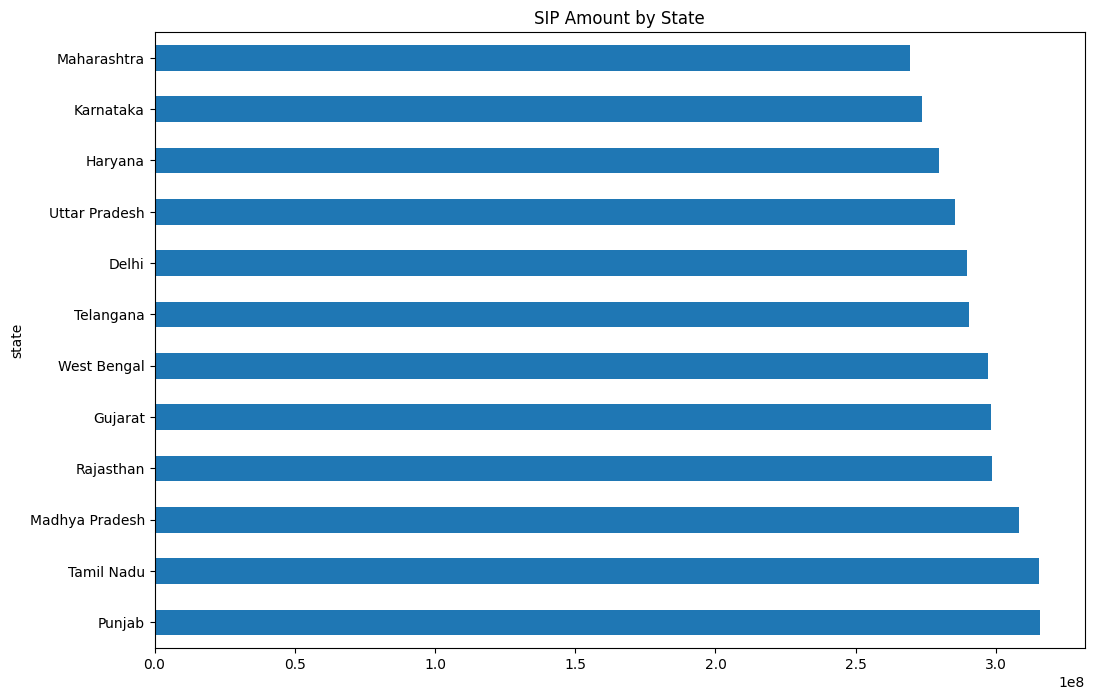

In [32]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title("SIP Amount by State")
plt.savefig(
    "../reports/charts/statewise_sip.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

## City Tier Distribution 

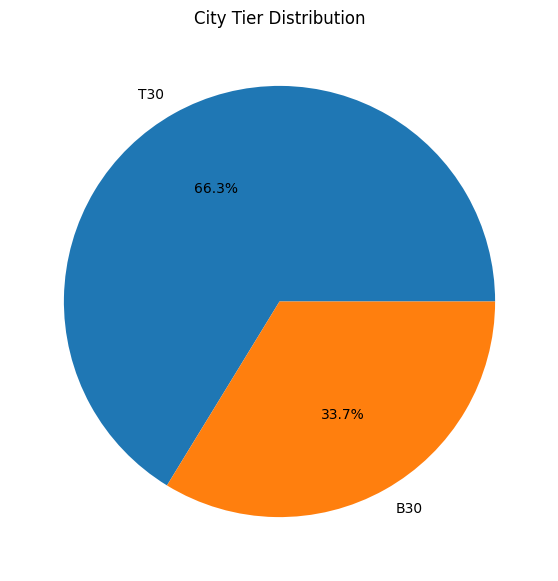

In [33]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("City Tier Distribution")
plt.savefig(
    "../reports/charts/city_tier_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Insight 7

Tier-1 cities accounted for a significant proportion of investments, highlighting stronger mutual fund penetration in urban regions.

**Reference:** State-wise SIP Amount and City Tier Distribution

## Industry Folio Growth 

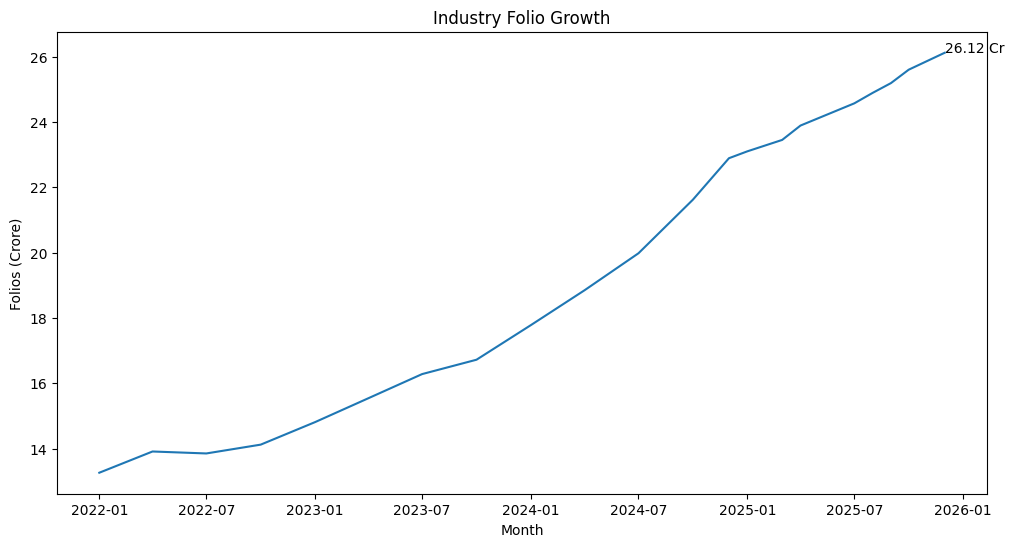

In [41]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.annotate(
    "26.12 Cr",
    xy=(folios["month"].iloc[-1],
        folios["total_folios_crore"].iloc[-1])
)
plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Insight 8

Industry folio counts nearly doubled between 2022 and 2025, reflecting rapid growth in the mutual fund investor base.

**Reference:** Industry Folio Growth

## Fund Return Correlation Matrix

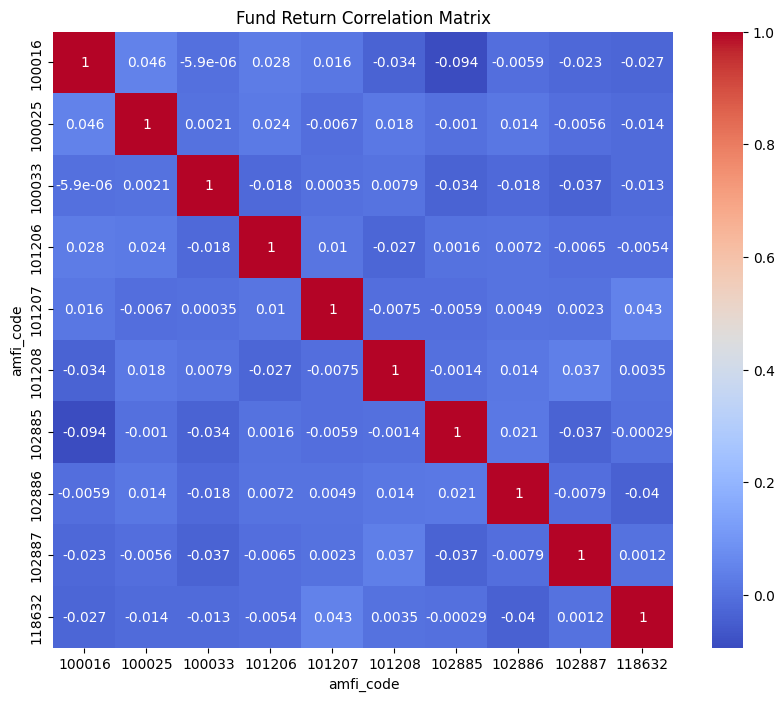

In [35]:
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")
plt.savefig(
    "../reports/charts/correlation_matrix.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Insight 9

Most selected funds demonstrated positive return correlations, suggesting that broader market movements influence fund performance.

**Reference:** Fund Return Correlation Matrix

## Sector Allocation

In [36]:
sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation"
)

fig.write_image(
    "../reports/charts/sector_allocation.png"
)

fig.show()

### Insight 10

Financial Services and Technology sectors represented a major share of portfolio allocation across equity mutual funds.

**Reference:** Sector Allocation Analysis

## Top 10 Funds by AUM 

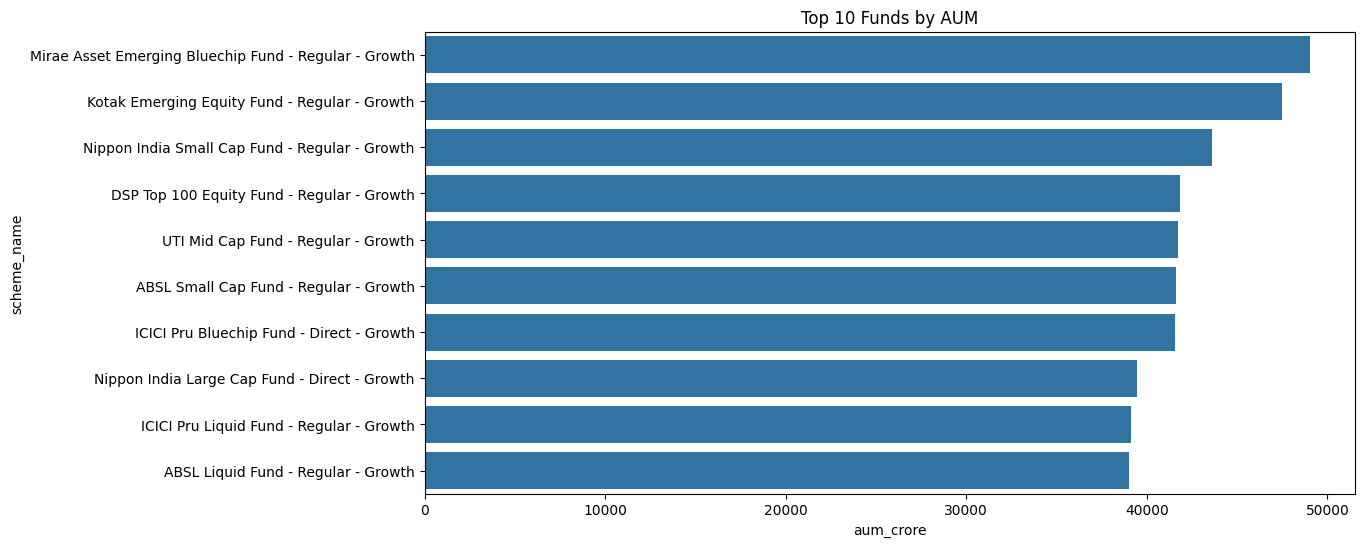

In [37]:
top_aum = performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")
plt.savefig(
    "../reports/charts/top10_funds_aum.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

## Expense Ratio Distribution 

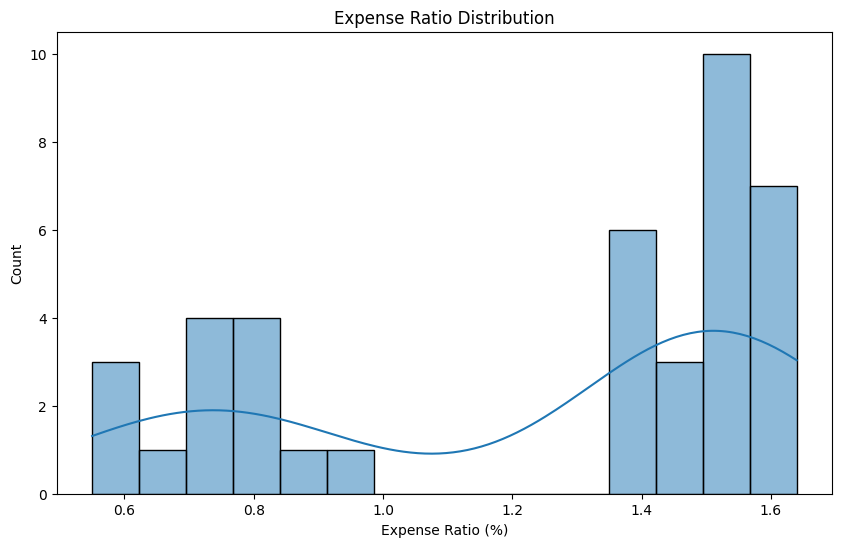

In [38]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.savefig(
    "../reports/charts/expense_ratio_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

## Risk Grade Distribution 

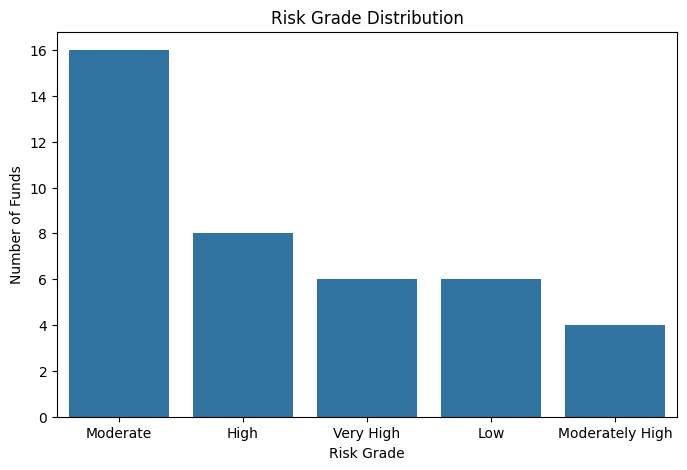

In [39]:
risk = performance["risk_grade"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=risk.index,
    y=risk.values
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")
plt.savefig(
    "../reports/charts/risk_grade_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

## Fund Category Distribution 

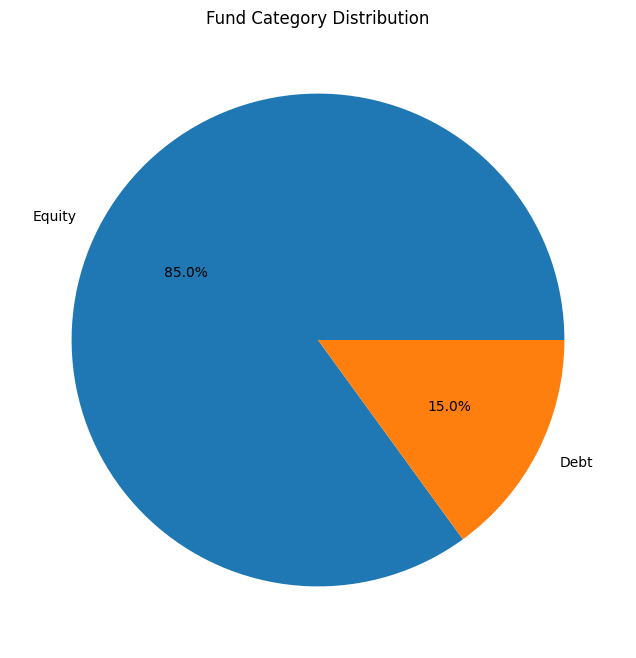

In [40]:
cat = funds["category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    cat,
    labels=cat.index,
    autopct="%1.1f%%"
)

plt.title("Fund Category Distribution")
plt.savefig(
    "../reports/charts/fund_category_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [44]:
findings = pd.DataFrame({
    "Finding No":[1,2,3,4,5,6,7,8,9,10],
    "Insight":[
        "NAV trends showed consistent long-term growth across most schemes.",
        "SBI Mutual Fund maintained the highest AUM among fund houses.",
        "Monthly SIP inflows increased steadily over the analysis period.",
        "SIP inflows reached their peak in December 2025.",
        "Equity-oriented categories attracted the highest net inflows.",
        "Investors aged 26-35 contributed the largest investment volume.",
        "Tier-1 cities accounted for a majority of investments.",
        "Industry folio counts nearly doubled between 2022 and 2025.",
        "Most selected funds exhibited positive return correlations.",
        "Financial Services and Technology sectors dominated portfolio allocations."
    ]
})

findings
findings.to_csv(
    "../reports/eda_findings.csv",
    index=False
)

# Key EDA Findings

1. Daily NAV trends indicate sustained long-term growth across most mutual fund schemes between 2022 and 2026.

2. AUM increased consistently across major fund houses, with SBI Mutual Fund maintaining the largest market share.

3. Monthly SIP inflows showed strong upward momentum throughout the analysis period.

4. SIP inflows reached their highest recorded level in December 2025, reflecting increased retail participation.

5. Equity-oriented categories attracted higher net inflows than most other fund categories.

6. Investors in the 25–35 age group contributed the largest share of transactions.

7. Tier-1 cities accounted for a significant proportion of mutual fund investments compared to smaller cities.

8. Industry folio counts nearly doubled between 2022 and 2025, indicating rapid growth in investor accounts.

9. Most selected funds demonstrated positive return correlations, suggesting common market-driven behaviour.

10. Financial Services and Technology sectors represented a major share of portfolio allocations across equity funds.